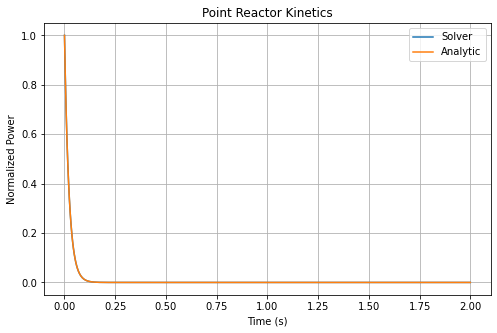

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
rho = 0.002
beta = 0.0065
Lambda = 1e-4

def kinetics(t, P):

    dPdt = ((rho-beta)/Lambda)*P

    return dPdt

sol = solve_ivp(
    kinetics,
    [0,2],
    [1],
    t_eval=np.linspace(0,2,500)
)

P_analytic = np.exp(
    ((0.002-beta)/Lambda)
    * sol.t
)

plt.figure(figsize=(8,5))

plt.plot(
    sol.t,
    sol.y[0],label="Solver"
)
plt.plot(
    sol.t,
    P_analytic,label="Analytic"
)
plt.xlabel("Time (s)")
plt.ylabel("Normalized Power")
plt.title("Point Reactor Kinetics")
plt.legend()
plt.grid(True)
plt.savefig(
    "reactor_kinetics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [2]:
reactivities = [
    -0.002,
     0.000,
     0.002,
     0.004
]

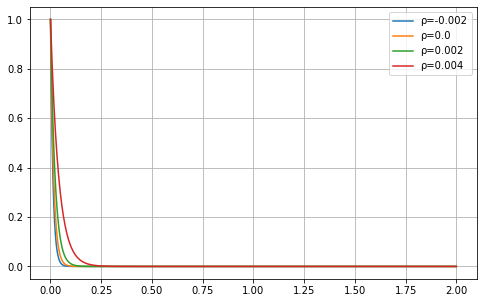

In [9]:
plt.figure(figsize=(8,5))

for rho in reactivities:

    def kinetics(t,P):
        return ((rho-beta)/Lambda)*P

    sol = solve_ivp(
        kinetics,
        [0,2],
        [1],
        t_eval=np.linspace(0,2,500)
    )

    plt.plot(
        sol.t,
        sol.y[0],
        label=f"ρ={rho}"
    )

plt.legend()
plt.grid()
plt.savefig(
    "reactor_kinetics_reactivities.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()